In [2]:
coefficients

array([0.07401667, 0.79867778])

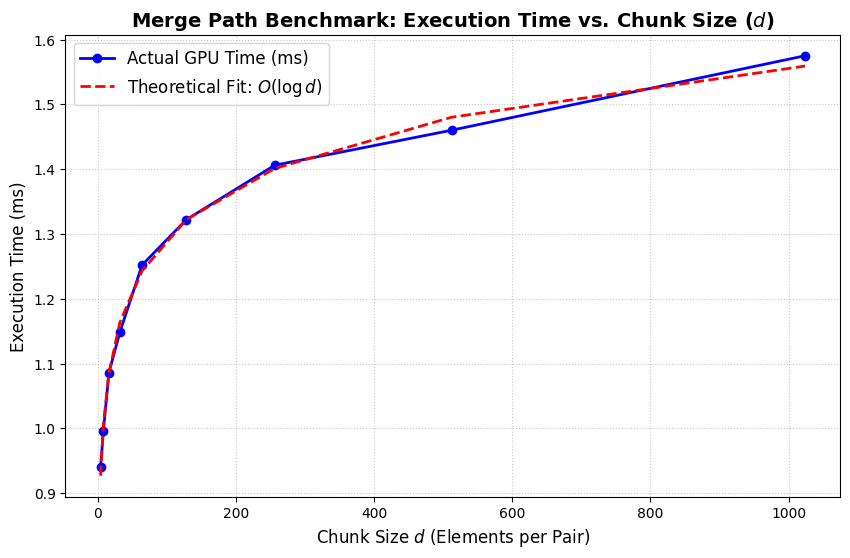

Logarithmic Fit Equation: Time = 0.0790 * log2(d) + 0.7689


In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Your benchmark data
d_values = np.array([4, 8, 16, 32, 64, 128, 256, 512, 1024])
time_ms = np.array([0.941, 0.996, 1.086, 1.149, 1.252, 1.322, 1.406, 1.460, 1.575])

# 2. Calculate the theoretical log(d) fit
# We fit a line to the equation: time = a * log2(d) + b
log2_d = np.log2(d_values)
coefficients = np.polyfit(log2_d, time_ms, 1) # Linear fit on the log values
poly_function = np.poly1d(coefficients)
theoretical_time = poly_function(log2_d)

# 3. Create the plot
plt.figure(figsize=(10, 6))

# Plot actual data
plt.plot(d_values, time_ms, marker='o', linestyle='-', color='blue', linewidth=2, label='Actual GPU Time (ms)')

# Plot theoretical curve
plt.plot(d_values, theoretical_time, linestyle='--', color='red', linewidth=2, label='Theoretical Fit: $O(\log d)$')

# 4. Formatting for a professional report
plt.title('Merge Path Benchmark: Execution Time vs. Chunk Size ($d$)', fontsize=14, fontweight='bold')
plt.xlabel('Chunk Size $d$ (Elements per Pair)', fontsize=12)
plt.ylabel('Execution Time (ms)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=12)

# Optional: Set x-axis to log scale to show the points evenly spaced
# plt.xscale('log', base=2) 

# Save the image in high resolution for your report
plt.savefig('benchmark_plot.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

print(f"Logarithmic Fit Equation: Time = {coefficients[0]:.4f} * log2(d) + {coefficients[1]:.4f}")